## Now use selective polynomial expansion with Lasso

## Commentary:



## Try RANSAC regression to model; compare to OLS


In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rc('figure', figsize=(10, 8))
np.set_printoptions(precision=4, suppress=False)
# please show all columns
pd.set_option("display.max_columns", 60)
import seaborn as sns
sns.set()

In [2]:
# Import sklearn stuff

from sklearn.linear_model import LinearRegression, Ridge, Lasso, RANSACRegressor
from sklearn.metrics import r2_score, mean_squared_error, make_scorer
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline,  make_pipeline, FeatureUnion
from sklearn.base import BaseEstimator, TransformerMixin

In [3]:
# read cleaned data
dfModelAll = pd.read_csv('../local/data/LBNL_openpv_tts_data/ModelAll.csv', index_col='row', dtype={'state':'category'})

In [4]:
# note data is sorted by time
dfModelAll.head()

,num_days,size_kw,state,cost_per_watt,scaleSize
row,,,,,
0,0.0,2.2824,CA,10.734315,0
1,21.0,1.8504,CA,11.108701,0
2,26.0,2.3076,CA,8.667013,0
3,84.0,2.3316,CA,13.270286,0
4,111.0,0.9300,CA,14.654839,0


In [5]:
dfModelAll.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 364212 entries, 0 to 364211
Data columns (total 5 columns):
num_days         364212 non-null float64
size_kw          364212 non-null float64
state            364212 non-null category
cost_per_watt    364212 non-null float64
scaleSize        364212 non-null int64
dtypes: category(1), float64(3), int64(1)
memory usage: 14.2 MB


### make a small dataset to try out the pipeline

In [6]:
dfMod100k = dfModelAll.sample(n=10000); dfMod100k.head()

,num_days,size_kw,state,cost_per_watt,scaleSize
row,,,,,
16022,2912.0,8.40,NJ,8.400000,3
193455,6109.0,7.00,MA,3.940000,2
233567,6460.0,8.97,CA,4.481605,3
16293,2925.0,6.00,CA,6.911665,2
291386,6669.0,4.34,NY,3.470000,1


### do one-hot encoding of $state$

In [7]:
dfMod100k = pd.get_dummies(dfMod100k, drop_first=True)

In [8]:
dfMod100k.head()

,num_days,size_kw,cost_per_watt,scaleSize,state_AZ,state_CA,state_CT,state_DE,state_FL,state_MA,state_MD,state_MN,state_NH,state_NJ,state_NM,state_NV,state_NY,state_OR,state_PA,state_TX,state_VT,state_WI
row,,,,,,,,,,,,,,,,,,,,,,
16022,2912.0,8.40,8.400000,3,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
193455,6109.0,7.00,3.940000,2,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
233567,6460.0,8.97,4.481605,3,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
16293,2925.0,6.00,6.911665,2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
291386,6669.0,4.34,3.470000,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0


### Also prep the whole data set.

### Important: since the data is sorted by time, it needs to be shuffed first or cross_val_score will pick bad sets.

In [9]:
# now the whole model; shuffle it though
dfMod = pd.get_dummies(dfModelAll, drop_first=True).sample(frac=1.0)

### Regress on time, size and state

In [10]:
theCols = dfMod100k.columns; theCols

Index(['num_days', 'size_kw', 'cost_per_watt', 'scaleSize', 'state_AZ',
       'state_CA', 'state_CT', 'state_DE', 'state_FL', 'state_MA', 'state_MD',
       'state_MN', 'state_NH', 'state_NJ', 'state_NM', 'state_NV', 'state_NY',
       'state_OR', 'state_PA', 'state_TX', 'state_VT', 'state_WI'],
      dtype='object')

#### chose one of these cells to set X and y

In [11]:
# prep data and target; this is about 30% of the data
X = dfMod100k[['num_days', 'size_kw', 'state_AZ',
              'state_CA', 'state_CT', 'state_DE', 'state_FL', 'state_MA', 'state_MD',
              'state_MN', 'state_NH', 'state_NJ', 'state_NM', 'state_NV', 'state_NY',
              'state_OR', 'state_PA', 'state_TX', 'state_VT', 'state_WI']]
y = dfMod100k[['cost_per_watt']]

In [12]:
# the whloe dataset - prep data and target
# X = dfMod[['num_days', 'size_kw', 'state_AZ',
#               'state_CA', 'state_CT', 'state_DE', 'state_FL', 'state_MA', 'state_MD',
#               'state_MN', 'state_NH', 'state_NJ', 'state_NM', 'state_NV', 'state_NY',
#               'state_OR', 'state_PA', 'state_TX', 'state_VT', 'state_WI']]
# y = dfMod[['cost_per_watt']]

### Bring in the right transformer

In [13]:
### make it an estimator and a transformer for general use
class ColumnExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None):
        self.columns = columns
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X_cols = X[self.columns]
        return X_cols

#### Make a pipeline for OLS

In [14]:
theStates = ['state_AZ', 'state_CA', 'state_CT', 'state_DE', 'state_FL', 'state_MA', 'state_MD',
             'state_MN', 'state_NH', 'state_NJ', 'state_NM', 'state_NV', 'state_NY', 'state_OR', 
             'state_PA', 'state_TX', 'state_VT', 'state_WI']

In [15]:
theOLSPipe = Pipeline([
    ('features', 
     FeatureUnion([('num_vars', 
                    Pipeline([('extract', ColumnExtractor(columns=['num_days', 'size_kw'])) ,
                              ('scale', StandardScaler()),
                              ('poly', PolynomialFeatures(degree=6))
                              ])),
                   ('cat_vars',
                    ColumnExtractor(columns=theStates))
                  ]) # end of FeatureUnion
    ),
    ('LR', LinearRegression())
]) # end of Pipeline

#### Make a pipeline for RANSAC

In [16]:
theRANSACPipe = Pipeline([
    ('features', 
     FeatureUnion([('num_vars', 
                    Pipeline([('extract', ColumnExtractor(columns=['num_days', 'size_kw'])) ,
                              ('scale', StandardScaler()),
                              ('poly', PolynomialFeatures(degree=6))
                              ])),
                   ('cat_vars',
                    ColumnExtractor(columns=theStates))
                  ]) # end of FeatureUnion
    ),
    ('RANSAC', RANSACRegressor())
]) # end of Pipeline

### Quickly check to see that OLS pipe is working.

In [17]:
# cross_val_score needs the data randomized not sorted that's why this works with small dataset but gives garbage for full ds.
cross_val_score(theOLSPipe, X, y, cv=4)

array([0.5256, 0.5076, 0.4902, 0.5077])

In [18]:
cross_val_score(theRANSACPipe, X, y, cv=4)

array([-3.0864e+02, -1.4991e+02, -2.0038e+05, -8.1397e+01])

---

need to do this a bit differently to figure out ransac.  First, build the data and just apply the regressor to it so we can get at all the pieces for messing around (without pulling them out of the pipeline).

In [19]:
# just build the data by running through first part of pipeline.
def buildModel(X, deg=6):
    pipe =  FeatureUnion([('num_vars', 
                    Pipeline([('extract', ColumnExtractor(columns=['num_days', 'size_kw'])) ,
                              ('scale', StandardScaler()),
                              ('poly', PolynomialFeatures(degree=6))
                              ])),
                   ('cat_vars',
                    ColumnExtractor(columns=theStates))
                  ])
    return pipe.fit_transform(X)

In [20]:
# build input from original
xX = buildModel(X); xX.shape

(10000, 46)

In [21]:
# make a ransacker
ransac = RANSACRegressor(residual_threshold=.5)

In [22]:
# fit it
rmodel = ransac.fit(xX, y)

In [23]:
# check it out
rmodel.estimator_.coef_, rmodel.estimator_.intercept_

(array([[ 2.2413e-14, -3.4598e+00, -2.2676e+00,  1.3035e+00, -2.7464e+00,
          1.3933e+00,  1.7233e+00,  1.8346e+00,  9.3708e-01,  3.3520e+00,
         -6.0917e-01,  3.4504e+00, -5.5541e+00,  6.6472e+00, -2.5728e+00,
          1.4627e-01, -1.1811e+00, -6.4420e-01, -1.1972e+00, -4.3533e-01,
         -1.0821e+00,  1.8996e-01, -1.1751e+00,  2.4597e+00, -4.2727e+00,
          2.0241e+00, -1.3747e+00,  6.6466e-01, -4.0930e-01,  6.3547e-01,
         -4.6201e-01,  5.7315e-02, -4.6755e-01,  2.2021e-02, -2.5586e-02,
          2.4185e-01,  1.3030e-01,  2.4953e-01, -1.2031e-02, -4.5051e-02,
          4.0034e-01, -4.5991e-02,  1.8085e-02,  1.3537e-02, -5.1180e-02,
         -2.4974e-01]]), array([5.1206]))

In [24]:
# params?
rmodel.get_params

<bound method BaseEstimator.get_params of RANSACRegressor(base_estimator=None, is_data_valid=None, is_model_valid=None,
        loss='absolute_loss', max_skips=inf, max_trials=100,
        min_samples=None, random_state=None, residual_metric=None,
        residual_threshold=0.5, stop_n_inliers=inf, stop_probability=0.99,
        stop_score=inf)>

In [25]:
inliersX=xX[rmodel.inlier_mask_]
inliersy=y[rmodel.inlier_mask_]
outliersX=xX[np.logical_not(rmodel.inlier_mask_)]
outliersy=y[np.logical_not(rmodel.inlier_mask_)]

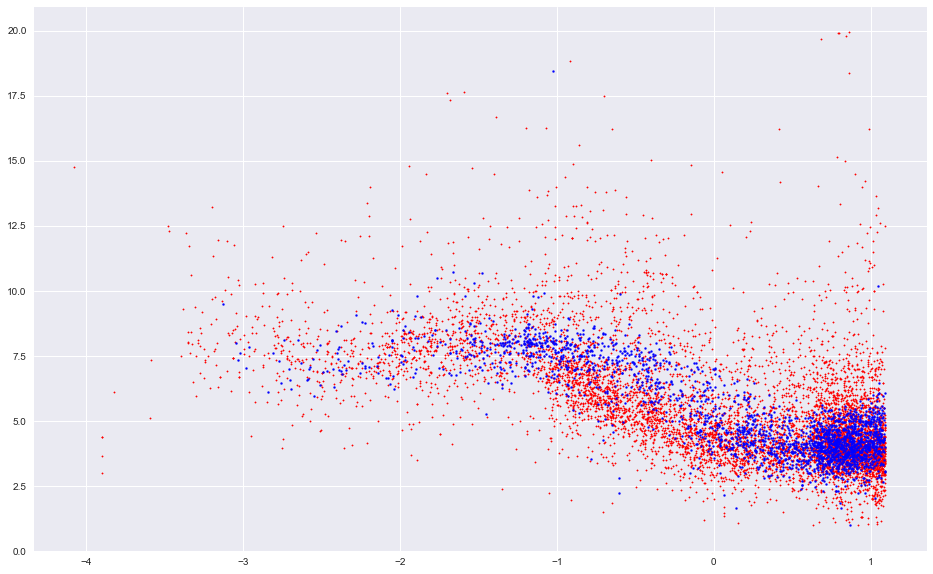

In [26]:
plt.figure(figsize=(16,10))

plt.scatter(x=outliersX[:,1],y=outliersy,color='r', s=2)
plt.scatter(x=inliersX[:,1],y=inliersy,color='b', s=4)

In [27]:
rmodel.score(xX, y)

-187618.94961558713